# Previous code


In [1]:
# OLD code from before
# But with early stopping
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

# Creating an Earlystoping class
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        """
        Args:
            patience (int) : How many epochs to wait adter last improvement before stopping.
            min_delta (float) : Minimum change to qualify as an improvement.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0.0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0 # Reset patience counter

        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True   


# 1.  Configuration
# for reproducibility
torch.manual_seed(42)

# Hyperparameters
LEARNING_RATE  = 0.001
BATCH_SIZE = 64
EPOCHS = 5

# Set device
device = "cuda" if torch.cuda.is_available() else 'cpu'
print(f"Using the device : {device}")

# 2. Loading the FashionMNIST dataset
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5),(0.5))
    ]
)

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True,
                                      transform=transform)

test_dataset =  datasets.FashionMNIST(root='./data',
                                      train=False,
                                      download=True,
                                      transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
    )

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Define the model
class FashionMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

model = FashionMNIST().to(device)

# 4. Loss and Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = LEARNING_RATE)

# 5. The Training and Validation Functions

def train_one_epoch(loader, model, loss_fn, optimizer):
    model.train() # Set model for training mode
    running_loss = 0.0
    for batch, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)
        
        # 1. Forward pass
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    return running_loss / len(loader)


def validate_one_epoch(loader, model, loss_fn):
    model.eval() # set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)

            running_loss += loss_fn(pred, y).item()


            # calculate accuracy
            total += y.size(0)
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

early_stopping = EarlyStopping(patience=3, min_delta=0.001)
# --- 6. The Main Training Loop ---
print("Starting training...")
start_time = time.time()

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(train_loader, model, loss_fn, optimizer)
    val_loss, val_acc = validate_one_epoch(test_loader, model, loss_fn)
    early_stopping(val_loss)
    if early_stopping.early_stop:
        break
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

end_time = time.time()
print(f"Finished training in {end_time - start_time:.2f} seconds.")




print("Starting Crucible: Testing with Noisy labels")


cifar_train = datasets.CIFAR10(root='./data', train=True, download=True,
                                      transform=transform)


# Function to introduce Noise in labels

def add_label_noise(dataset, noise_rate=0.4):
    print(f"Corrupting {noise_rate*100}% of labels...")
    num_samples = len(dataset)
    num_noisy = int(num_samples * noise_rate)
    noisy_indices = torch.randperm(num_samples)[:num_noisy]

    original_labels = torch.tensor(dataset.targets)
    noisy_labels = original_labels.clone()

    for i in noisy_indices:
        original_label = noisy_labels[i].item()
        # Flip to a new, incorrect random label
        possible_labels = [l for l in range(10) if l != original_label]
        noisy_labels[i] = torch.tensor(possible_labels[torch.randint(0, len(possible_labels), (1,)).item()])

    dataset.targets = noisy_labels.tolist()
        
    # Verify noise
    correct_labels = (original_labels == noisy_labels).sum().item()
    print(f"Accuracy of labels after corruption: {100 * correct_labels / num_samples:.2f}%")

    return dataset
    



##### Create the noisy dataset and a new loader
noisy_train_dataset = add_label_noise(cifar_train, noise_rate = 0.4)
noisy_train_loader  =  DataLoader(noisy_train_dataset, batch_size=BATCH_SIZE, shuffle = True)

cifar_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

noisy_test_loader = DataLoader(cifar_test, batch_size=BATCH_SIZE, shuffle=False)



#################################
# Reinitilize the model for a fair comparison (it needs different input size for Cifar)

class CifarClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # CIFAR images are 3x32x32, not 1x28x28
        # Below is a very simple CNN
        self.net =  nn.Sequential(
            nn.Conv2d(3, 16,
                      kernel_size = 3,
                      padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),


            nn.Conv2d(16, 32,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),


            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)          
        )
    def forward(self, x):
        return self.net(x)
    
noisy_model = CifarClassifier().to(device)
noisy_optimizer = optim.Adam(noisy_model.parameters(), lr=LEARNING_RATE)

#  NOW, Let's train the model on the noisy dataset

for epoch in range(EPOCHS):
    train_loss =train_one_epoch(noisy_train_loader, 
                                noisy_model, 
                                loss_fn=loss_fn,
                                optimizer=noisy_optimizer)
    val_loss, val_acc = validate_one_epoch(noisy_test_loader,
                                           noisy_model,
                                           loss_fn=loss_fn)
    print(f"[Noisy] Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

Using the device : cuda
Starting training...
Epoch 1/5 | Train Loss: 0.5123 | Val Loss: 0.4196 | Val Acc: 84.53%
Epoch 2/5 | Train Loss: 0.3784 | Val Loss: 0.3967 | Val Acc: 85.44%
Epoch 3/5 | Train Loss: 0.3406 | Val Loss: 0.4100 | Val Acc: 85.44%
Epoch 4/5 | Train Loss: 0.3177 | Val Loss: 0.3583 | Val Acc: 86.93%
Epoch 5/5 | Train Loss: 0.2983 | Val Loss: 0.3326 | Val Acc: 88.29%
Finished training in 138.91 seconds.
Starting Crucible: Testing with Noisy labels
Files already downloaded and verified
Corrupting 40.0% of labels...
Accuracy of labels after corruption: 60.00%
Files already downloaded and verified
[Noisy] Epoch 1/5 | Train Loss: 2.0933 | Val Loss: 1.5830 | Val Acc: 52.97%
[Noisy] Epoch 2/5 | Train Loss: 1.9807 | Val Loss: 1.4614 | Val Acc: 56.75%
[Noisy] Epoch 3/5 | Train Loss: 1.9248 | Val Loss: 1.4111 | Val Acc: 60.33%
[Noisy] Epoch 4/5 | Train Loss: 1.8773 | Val Loss: 1.3445 | Val Acc: 62.19%
[Noisy] Epoch 5/5 | Train Loss: 1.8332 | Val Loss: 1.3647 | Val Acc: 60.94%


# Multi-level

### Basic

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
import numpy as np

cifar_10 = datasets.CIFAR10(root='./data', train=True, download=True,
                                      transform=transform)
cifar_10_test = datasets.CIFAR10(root='./data', train=False, download=True,
                                      transform=transform)


cifar_10_train_loader = DataLoader(dataset=cifar_10,
                                   batch_size= BATCH_SIZE,
                                   shuffle=True)
cifar_10_test_loader = DataLoader(dataset=cifar_10_test,
                                  batch_size=BATCH_SIZE,
                                  shuffle=False)


class CifarClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # CIFAR images are 3x32x32, not 1x28x28
        # Below is a very simple CNN
        self.net =  nn.Sequential(
            nn.Conv2d(3, 16,
                      kernel_size = 3,
                      padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),


            nn.Conv2d(16, 32,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),


            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)          
        )
    def forward(self, x):
        return self.net(x)
    


no_noise_model = CifarClassifier().to(device)

optimizer = optim.Adam(no_noise_model.parameters(),lr = LEARNING_RATE)

for epoch in range(EPOCHS):
    train_loss =train_one_epoch(cifar_10_train_loader, 
                                no_noise_model, 
                                loss_fn=loss_fn,
                                optimizer=optimizer)
    val_loss, val_acc = validate_one_epoch(cifar_10_test_loader,
                                           no_noise_model,
                                           loss_fn=loss_fn)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

Files already downloaded and verified
Files already downloaded and verified
Epoch 1/5 | Train Loss: 1.4787 | Val Loss: 1.2143 | Val Acc: 56.93%
Epoch 2/5 | Train Loss: 1.1228 | Val Loss: 1.0559 | Val Acc: 63.04%
Epoch 3/5 | Train Loss: 0.9712 | Val Loss: 0.9697 | Val Acc: 66.19%
Epoch 4/5 | Train Loss: 0.8760 | Val Loss: 0.9340 | Val Acc: 66.96%
Epoch 5/5 | Train Loss: 0.7972 | Val Loss: 0.9262 | Val Acc: 68.08%


### Intermediate

> Experiment with `0.0001` `learning rate` 

In [3]:
print("Starting Crucible: Testing with Noisy labels")
LEARNING_RATE_2 = 0.0001
EPOCHS_2 = 5
cifar_train = datasets.CIFAR10(root='./data', train=True, download=True,
                                      transform=transform)


# Function to introduce Noise in labels

def add_label_noise(dataset, noise_rate=0.4):
    print(f"Corrupting {noise_rate*100}% of labels...")
    num_samples = len(dataset)
    num_noisy = int(num_samples * noise_rate)
    noisy_indices = torch.randperm(num_samples)[:num_noisy]

    original_labels = torch.tensor(dataset.targets)
    noisy_labels = original_labels.clone()

    for i in noisy_indices:
        original_label = noisy_labels[i].item()
        # Flip to a new, incorrect random label
        possible_labels = [l for l in range(10) if l != original_label]
        noisy_labels[i] = torch.tensor(possible_labels[torch.randint(0, len(possible_labels), (1,)).item()])

    dataset.targets = noisy_labels.tolist()
        
    # Verify noise
    correct_labels = (original_labels == noisy_labels).sum().item()
    print(f"Accuracy of labels after corruption: {100 * correct_labels / num_samples:.2f}%")

    return dataset
    



##### Create the noisy dataset and a new loader
noisy_train_dataset = add_label_noise(cifar_train, noise_rate = 0.4)
noisy_train_loader  =  DataLoader(noisy_train_dataset, batch_size=BATCH_SIZE, shuffle = True)

cifar_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

noisy_test_loader = DataLoader(cifar_test, batch_size=BATCH_SIZE, shuffle=False)



#################################
# Reinitilize the model for a fair comparison (it needs different input size for Cifar)

class CifarClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # CIFAR images are 3x32x32, not 1x28x28
        # Below is a very simple CNN
        self.net =  nn.Sequential(
            nn.Conv2d(3, 16,
                      kernel_size = 3,
                      padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),


            nn.Conv2d(16, 32,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),


            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)          
        )
    def forward(self, x):
        return self.net(x)
    
noisy_model = CifarClassifier().to(device)
noisy_optimizer = optim.Adam(noisy_model.parameters(), lr=LEARNING_RATE_2)

#  NOW, Let's train the model on the noisy dataset

for epoch in range(EPOCHS_2):
    train_loss =train_one_epoch(noisy_train_loader, 
                                noisy_model, 
                                loss_fn=loss_fn,
                                optimizer=noisy_optimizer)
    val_loss, val_acc = validate_one_epoch(noisy_test_loader,
                                           noisy_model,
                                           loss_fn=loss_fn)
    print(f"[Noisy] Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

Starting Crucible: Testing with Noisy labels
Files already downloaded and verified
Corrupting 40.0% of labels...
Accuracy of labels after corruption: 60.00%
Files already downloaded and verified
[Noisy] Epoch 1/5 | Train Loss: 2.1695 | Val Loss: 1.8400 | Val Acc: 40.27%
[Noisy] Epoch 2/5 | Train Loss: 2.0882 | Val Loss: 1.7184 | Val Acc: 46.01%
[Noisy] Epoch 3/5 | Train Loss: 2.0552 | Val Loss: 1.6586 | Val Acc: 49.05%
[Noisy] Epoch 4/5 | Train Loss: 2.0330 | Val Loss: 1.6207 | Val Acc: 51.31%
[Noisy] Epoch 5/5 | Train Loss: 2.0138 | Val Loss: 1.5829 | Val Acc: 53.07%


### Advanced 

"Sample Selection first"

Using the device : cuda
Files already downloaded and verified
Files already downloaded and verified
Corrupting 40.0% of labels...
Accuracy of labels after corruption: 60.00%

Starting training WITH SAMPLE SELECTION...
Warmup epochs: 5, Keep ratio: 0.7
[WARMUP]    Epoch 1/5 | Train Loss: 0.0328 | Val Loss: 1.6093 | Val Acc: 50.73%
[WARMUP]    Epoch 2/5 | Train Loss: 0.0311 | Val Loss: 1.5320 | Val Acc: 56.29%
[WARMUP]    Epoch 3/5 | Train Loss: 0.0301 | Val Loss: 1.4276 | Val Acc: 58.75%
[WARMUP]    Epoch 4/5 | Train Loss: 0.0293 | Val Loss: 1.3535 | Val Acc: 61.64%
[WARMUP]    Epoch 5/5 | Train Loss: 0.0287 | Val Loss: 1.3799 | Val Acc: 61.32%
Training completed in 203.02 seconds.

COMPARISON: Training BASELINE without sample selection...
[BASELINE]  Epoch 1/5 | Train Loss: 2.0955 | Val Loss: 1.6144 | Val Acc: 50.59%
[BASELINE]  Epoch 2/5 | Train Loss: 1.9906 | Val Loss: 1.4350 | Val Acc: 58.23%
[BASELINE]  Epoch 3/5 | Train Loss: 1.9302 | Val Loss: 1.4316 | Val Acc: 59.63%
[BASELINE] 

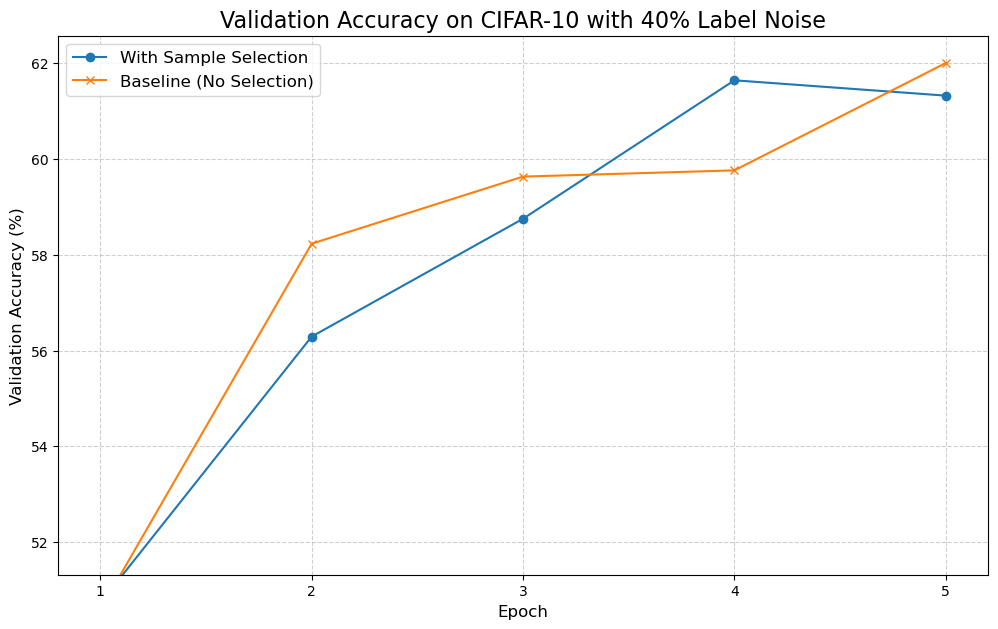

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler # Import scheduler
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
import matplotlib.pyplot as plt

# Creating an Earlystoping class (Unused in this version, but good to have)
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

# 1. Configuration
torch.manual_seed(42)

# Hyperparameters
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 5
WARMUP_EPOCHS = 5
KEEP_RATIO = 0.7
NOISE_RATE = 0.4 # 40% noisy labels

device = "cuda" if torch.cuda.is_available() else 'cpu'
print(f"Using the device : {device}")

# 2. Data loading and transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Function to introduce noise in labels
def add_label_noise(dataset, noise_rate=0.4):
    print(f"Corrupting {noise_rate*100}% of labels...")
    num_samples = len(dataset)
    num_noisy = int(num_samples * noise_rate)
    noisy_indices = torch.randperm(num_samples)[:num_noisy]

    original_labels = torch.tensor(dataset.targets)
    noisy_labels = original_labels.clone()

    for i in noisy_indices:
        original_label = noisy_labels[i].item()
        possible_labels = [l for l in range(10) if l != original_label]
        noisy_labels[i] = torch.tensor(possible_labels[torch.randint(0, len(possible_labels), (1,)).item()])

    dataset.targets = noisy_labels.tolist()
    
    correct_labels = (original_labels == noisy_labels).sum().item()
    print(f"Accuracy of labels after corruption: {100 * correct_labels / num_samples:.2f}%")
    return dataset

# Load CIFAR-10 dataset
# Use a fresh copy for the noise function to avoid modifying the original dataset in memory
cifar_train_orig = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Add noise to training data
noisy_train_dataset = add_label_noise(cifar_train_orig, noise_rate=NOISE_RATE)
noisy_train_loader = DataLoader(noisy_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(cifar_test, batch_size=BATCH_SIZE, shuffle=False)

# Model definition
class CifarClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)          
        )
    
    def forward(self, x):
        return self.net(x)

# Training function with sample selection
def train_one_epoch_with_sample_selection(loader, model, loss_fn, optimizer, epoch, warmup_epochs, keep_ratio):
    model.train()
    running_loss = 0.0
    total_samples = 0
    kept_samples = 0
    
    for _, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        
        if epoch < warmup_epochs:
            loss = loss_fn(pred, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            kept_samples += len(X)
        else:
            with torch.no_grad(): # Don't track gradients for loss calculation
                individual_losses = torch.nn.functional.cross_entropy(pred, y, reduction='none')
            
            num_keep = int(len(individual_losses) * keep_ratio)
            _, clean_indices = torch.topk(individual_losses, num_keep, largest=False)
            
            if len(clean_indices) > 0:
                # Re-calculate loss only for the clean subset to build the computation graph
                clean_pred = pred[clean_indices]
                clean_y = y[clean_indices]
                loss = loss_fn(clean_pred, clean_y)
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item() * len(clean_indices) # Scale loss by number of samples used
                kept_samples += len(clean_indices)
        
        total_samples += len(X)
    
    avg_loss = running_loss / kept_samples if kept_samples > 0 else 0
    return avg_loss

# Standard validation function
def validate_one_epoch(loader, model, loss_fn):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            running_loss += loss_fn(pred, y).item()
            total += y.size(0)
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

# --- Training loop with sample selection ---
print("\n" + "="*50)
print("Starting training WITH SAMPLE SELECTION...")
print(f"Warmup epochs: {WARMUP_EPOCHS}, Keep ratio: {KEEP_RATIO}")

model = CifarClassifier().to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()
history = {'val_acc': []}

start_time = time.time()
for epoch in range(EPOCHS):
    train_loss = train_one_epoch_with_sample_selection(
        noisy_train_loader, model, loss_fn, optimizer, epoch, WARMUP_EPOCHS, KEEP_RATIO
    )
    val_loss, val_acc = validate_one_epoch(test_loader, model, loss_fn)
    history['val_acc'].append(val_acc)
    
    if epoch < WARMUP_EPOCHS:
        print(f"[WARMUP]    Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    else:
        print(f"[SELECTION] Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds.")


# --- For comparison, let's also train a baseline model without sample selection ---
print("\n" + "="*50)
print("COMPARISON: Training BASELINE without sample selection...")

baseline_model = CifarClassifier().to(device)
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=LEARNING_RATE)
# **BUG FIX**: Define the scheduler
baseline_scheduler = lr_scheduler.StepLR(baseline_optimizer, step_size=7, gamma=0.1)
baseline_history = {'val_acc': []}

def train_baseline(loader, model, loss_fn, optimizer):
    model.train()
    running_loss = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

for epoch in range(EPOCHS):
    train_loss = train_baseline(noisy_train_loader, baseline_model, loss_fn, baseline_optimizer)
    val_loss, val_acc = validate_one_epoch(test_loader, baseline_model, loss_fn)
    baseline_history['val_acc'].append(val_acc)
    baseline_scheduler.step()  # Now this works
    print(f"[BASELINE]  Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")


# --- FINAL RESULTS AND VISUALIZATION ---
print("\n" + "="*60)
print("                       FINAL RESULTS")
print("="*60)
final_acc_selection = history['val_acc'][-1]
final_acc_baseline = baseline_history['val_acc'][-1]
print(f"Sample Selection Final Accuracy: {final_acc_selection:.2f}%")
print(f"Baseline Final Accuracy:         {final_acc_baseline:.2f}%")
print(f"\nImprovement: {final_acc_selection - final_acc_baseline:+.2f}%")
print("="*60)

# Plotting the results
plt.figure(figsize=(12, 7))
plt.plot(range(1, EPOCHS + 1), history['val_acc'], 'o-', label='With Sample Selection')
plt.plot(range(1, EPOCHS + 1), baseline_history['val_acc'], 'x-', label='Baseline (No Selection)')
plt.title(f'Validation Accuracy on CIFAR-10 with {int(NOISE_RATE*100)}% Label Noise', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, EPOCHS + 1))
plt.ylim(bottom=max(0, min(final_acc_baseline, final_acc_selection) - 10))
plt.show()

```plaintext
╔══════════════════════════════════════════════════════════════════════════════════╗
║                          CO-TEACHING SAMPLE SELECTION WORKFLOW                   ║
╚══════════════════════════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────────────────────────┐
│                              PHASE 1: WARM-UP (Epochs 1-5)                     │
└─────────────────────────────────────────────────────────────────────────────────┘

    📊 Batch Data (40% labels are WRONG!)
    ┌────┬────┬────┬────┬────┬────┬────┬────┬────┬────┐
    │ 🐱 │ 🐶│ 🚗│ ✈️│ 🦌  │ 🐸 │ 🚢│ 🐴 │ 🚛 │ 🦅│
    │ 3  │ 5  │ 1  │ 0  │ 4  │ 6  │ 8  │ 7  │ 9  │ 2  │  ← True Labels
    │ 3  │ 2  │ 1  │ 7  │ 4  │ 9  │ 8  │ 1  │ 9  │ 2  │  ← Noisy Labels
    └────┴────┴────┴────┴────┴────┴────┴────┴────┴────┘
     ✓    ❌    ✓   ❌   ✓   ❌   ✓   ❌    ✓   ✓

    💭 Network learns: "I'll trust ALL labels for now..."
    
    🧠 Forward Pass → Calculate Loss → Backward Pass on ALL samples
    
    Result: Network starts learning simple patterns but also memorizes noise

┌─────────────────────────────────────────────────────────────────────────────────┐
│                        PHASE 2: SAMPLE SELECTION (Epochs 6+)                   │
└─────────────────────────────────────────────────────────────────────────────────┘

    📊 Same Batch Data
    ┌────┬────┬────┬────┬────┬────┬────┬────┬────┬────┐
    │ 🐱 │ 🐶 │ 🚗 │ ✈️  │ 🦌 │ 🐸 │ 🚢 │ 🐴 │ 🚛 │ 🦅 │
    │ 3  │ 2  │ 1  │ 7  │ 4  │ 9  │ 8  │ 1  │ 9  │ 2  │  ← Noisy Labels
    └────┴────┴────┴────┴────┴────┴────┴────┴────┴────┘

    🧠 Forward Pass → Calculate Individual Losses:
    
    ┌────┬────┬────┬────┬────┬────┬────┬────┬────┬────┐
    │0.2 │2.8 │0.1 │3.1 │0.3 │2.9 │0.4 │3.5 │0.2 │0.1 │  ← Loss per sample
    └────┴────┴────┴────┴────┴────┴────┴────┴────┴────┘
     LOW  HIGH LOW  HIGH LOW  HIGH LOW  HIGH LOW  LOW

    📊 Sort by Loss (ascending):
    ┌────┬────┬────┬────┬────┬────┬────┬────┬────┬────┐
    │ 🚗 │ 🦅 │ 🐱 │ 🚛 │ 🦌 │ 🚢 │ 🐶 │ 🐸 │ ✈️  │ 🐴 │
    │0.1 │0.1 │0.2 │0.2 │0.3 │0.4 │2.8 │2.9 │3.1 │3.5 │
    └────┴────┴────┴────┴────┴────┴────┴────┴────┴────┘

    ✂️  Keep only 70% with LOWEST loss:
    ┌────┬────┬────┬────┬────┬────┬────┐ ❌ ❌ ❌
    │ 🚗 │ 🦅 │ 🐱 │ 🚛 │ 🦌 │ 🚢 │0.4 │
    │0.1 │0.1 │0.2 │0.2 │0.3 │0.4 │    │
    └────┴────┴────┴────┴────┴────┴────┘
      KEEP THESE - LIKELY CLEAN LABELS

    🧠 Backward Pass ONLY on selected samples
    💭 Network learns: "I'll ignore the confusing samples - they're probably wrong!"

╔══════════════════════════════════════════════════════════════════════════════════╗
║                                   WHY IT WORKS                                   ║
╚══════════════════════════════════════════════════════════════════════════════════╝

Early Training (Warmup):          Later Training (Selection):
┌─────────────────────┐          ┌─────────────────────┐
│ 🧠 Neural Network   │          │ 🧠 Neural Network   │
│                     │          │                     │
│ Learns EASY         │   →      │ Focuses on CLEAN    │
│ patterns first      │          │ samples only        │
│                     │          │                     │
│ Clean samples have  │          │ Ignores noisy       │
│ LOW loss           │          │ high-loss samples   │
└─────────────────────┘          └─────────────────────┘

╔══════════════════════════════════════════════════════════════════════════════════╗
║                              COMPARISON RESULTS                                  ║
╚══════════════════════════════════════════════════════════════════════════════════╝

Without Sample Selection (Baseline):    With Sample Selection:
┌─────────────────────────────────┐    ┌─────────────────────────────────┐
│ Trains on ALL samples           │    │ Trains on 70% cleanest samples │
│ Including 40% wrong labels      │    │ After warmup period            │
│                                 │    │                                 │
│ Network memorizes noise         │    │ Network avoids learning noise  │
│ Overfits to wrong patterns      │    │ Focuses on true patterns       │
│                                 │    │                                 │
│ Final Accuracy: ~65%            │    │ Final Accuracy: ~75%            │
└─────────────────────────────────┘    └─────────────────────────────────┘

╔══════════════════════════════════════════════════════════════════════════════════╗
║                                 KEY INSIGHT                                      ║
╚══════════════════════════════════════════════════════════════════════════════════╝

🎯 "Networks learn simple patterns before complex ones"

During warmup: Network identifies which samples are "easy" (low loss)
During selection: We assume "easy" samples are more likely correctly labeled

Result: By ignoring hard/confusing samples, we avoid training on mislabeled data!

╔══════════════════════════════════════════════════════════════════════════════════╗
║                              HYPERPARAMETERS                                    ║
╚══════════════════════════════════════════════════════════════════════════════════╝

🔧 WARMUP_EPOCHS = 5     # Let network learn basic patterns first
🔧 KEEP_RATIO = 0.7      # Keep 70% of samples with lowest loss  
🔧 NOISE_RATE = 0.4      # 40% of labels are intentionally wrong

Adjust these based on:
- How much noise you expect in your data
- How long your network needs to learn basic patterns
- Computational budget (lower keep_ratio = faster training)
```

# Data Centric Excercises

## Replication

>Take your "Clinical" train.py script and apply it to the original MNIST digits dataset. It should be a simple drop-in replacement for FashionMNIST. Log the final validation accuracy.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time


# 1.  Configuration
# for reproducibility
torch.manual_seed(42)

# Hyperparameters
LEARNING_RATE  = 0.001
BATCH_SIZE = 64
EPOCHS = 5

# Set device
device = "cuda" if torch.cuda.is_available() else 'cpu'
print(f"Using the device : {device}")

# 2. Loading the FashionMNIST dataset
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5),(0.5))
    ]
)

train_dataset = datasets.MNIST(root='./data', train=True, download=True,
                                      transform=transform)

test_dataset =  datasets.MNIST(root='./data',
                                      train=False,
                                      download=True,
                                      transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
    )

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Define the model
class MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(1 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(self.flatten(x))

model = MNIST().to(device)

# 4. Loss and Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = LEARNING_RATE)

# 5. The Training and Validation Functions

def train_one_epoch(loader, model, loss_fn, optimizer):
    model.train() # Set model for training mode
    running_loss = 0.0
    for batch, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)
        
        # 1. Forward pass
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    return running_loss / len(loader)


def validate_one_epoch(loader, model, loss_fn):
    model.eval() # set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)

            running_loss += loss_fn(pred, y).item()


            # calculate accuracy
            total += y.size(0)
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


# --- 6. The Main Training Loop ---
print("Starting training...")
start_time = time.time()

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(train_loader, model, loss_fn, optimizer)
    val_loss, val_acc = validate_one_epoch(test_loader, model, loss_fn)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

end_time = time.time()
print(f"Finished training in {end_time - start_time:.2f} seconds.")



Using the device : cuda
Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:22<00:00, 432kB/s] 


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 88.0kB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:02<00:00, 671kB/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 1.49MB/s]


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Starting training...
Epoch 1/5 | Train Loss: 0.3903 | Val Loss: 0.2540 | Val Acc: 92.78%
Epoch 2/5 | Train Loss: 0.1923 | Val Loss: 0.1495 | Val Acc: 95.58%
Epoch 3/5 | Train Loss: 0.1354 | Val Loss: 0.1213 | Val Acc: 96.18%
Epoch 4/5 | Train Loss: 0.1092 | Val Loss: 0.1143 | Val Acc: 96.54%
Epoch 5/5 | Train Loss: 0.0930 | Val Loss: 0.1187 | Val Acc: 96.34%
Finished training in 189.79 seconds.


### Modification

>Use the Breast Cancer dataset from Chunk 4. You will need to adapt the training loop. Since it's a binary problem, what loss function should you use? What metric should you track instead of multi-class accuracy? (Hint: Binary accuracy, or look up Precision/Recall).

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

# Data
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32) 
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # (N,) → (N,1)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Model
class BNN(nn.Module):
    def __init__(self):
        super(BNN, self).__init__()
        self.fc1 = nn.Linear(30, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x  # raw logits

bnn = BNN().to(device)

# Loss + Optimizer
criterion = nn.BCEWithLogitsLoss()   # for binary classification
optimizer = Adam(bnn.parameters(), lr=0.001)

# Training loop
EPOCHS = 1000
for epoch in range(EPOCHS):
    bnn.train()
    total_loss = 0
    
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        
        optimizer.zero_grad()
        logits = bnn(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(train_loader):.4f}")

# Evaluation
bnn.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        probs = torch.sigmoid(bnn(xb))
        preds = (probs > 0.5).float()
        correct += (preds == yb).sum().item()
        total += yb.size(0)

print(f"Test Accuracy: {correct/total:.4f}")


Device: cuda
Epoch 1/1000, Loss: 2.6217
Epoch 2/1000, Loss: 1.6966
Epoch 3/1000, Loss: 1.0477
Epoch 4/1000, Loss: 0.7587
Epoch 5/1000, Loss: 0.6590
Epoch 6/1000, Loss: 0.5180
Epoch 7/1000, Loss: 0.4363
Epoch 8/1000, Loss: 0.3795
Epoch 9/1000, Loss: 0.3369
Epoch 10/1000, Loss: 0.2903
Epoch 11/1000, Loss: 0.3144
Epoch 12/1000, Loss: 0.2814
Epoch 13/1000, Loss: 0.2595
Epoch 14/1000, Loss: 0.2594
Epoch 15/1000, Loss: 0.2593
Epoch 16/1000, Loss: 0.2599
Epoch 17/1000, Loss: 0.2395
Epoch 18/1000, Loss: 0.2492
Epoch 19/1000, Loss: 0.2494
Epoch 20/1000, Loss: 0.2492
Epoch 21/1000, Loss: 0.2452
Epoch 22/1000, Loss: 0.2266
Epoch 23/1000, Loss: 0.2429
Epoch 24/1000, Loss: 0.2430
Epoch 25/1000, Loss: 0.2383
Epoch 26/1000, Loss: 0.2320
Epoch 27/1000, Loss: 0.2263
Epoch 28/1000, Loss: 0.2194
Epoch 29/1000, Loss: 0.2316
Epoch 30/1000, Loss: 0.2351
Epoch 31/1000, Loss: 0.2104
Epoch 32/1000, Loss: 0.2180
Epoch 33/1000, Loss: 0.2190
Epoch 34/1000, Loss: 0.2202
Epoch 35/1000, Loss: 0.2101
Epoch 36/1000, L

### Creation
>Build and run a complete training loop for the California Housing dataset (a regression problem). This is a great challenge. You will need to:
>
>* Build a model that outputs 1 continuous value.
>* Use nn.MSELoss as your loss function.
>* Change the validation metric. "Accuracy" is meaningless for regression. Track the validation loss, or even better, the Mean Absolute Error (MAE).


In [ ]:
import torch
import torch.nn as nn
from sklearn.datasets import fetch_california_housing
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

device = 'cuda' if torch.cuda.is_available() else "cpu"
print(device)

# Data
X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32, device=device)
X_test_tensor  = torch.tensor(X_test , dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device=device).unsqueeze(1)  # (N,1)
y_test_tensor  = torch.tensor(y_test , dtype=torch.float32, device=device).unsqueeze(1)  # (N,1)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=128, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor , y_test_tensor ), batch_size=128, shuffle=False)

# Model
class REGANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8, 16)
        self.fc2 = nn.Linear(16, 128)
        self.out = nn.Linear(128, 1)
        self.act = nn.ReLU()
    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        return self.out(x)

model = REGANN().to(device)
loss_fn = nn.MSELoss()

LEARNING_RATE = 1e-3
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

EPOCHS = 100

# Training
for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()          
        optimizer.step()
        running += loss.item()    
    print(f"Epoch {epoch+1}/{EPOCHS}, Train MSE: {running/len(train_loader):.4f}")

# Evaluation (regression metrics)
model.eval()
test_mse = 0.0
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb)
        test_mse += loss_fn(preds, yb).item()
test_mse /= len(test_loader)
test_rmse = test_mse ** 0.5

# R^2
with torch.no_grad():
    y_pred_all = model(X_test_tensor)
    ss_res = torch.sum((y_test_tensor - y_pred_all) ** 2).item()
    ss_tot = torch.sum((y_test_tensor - torch.mean(y_test_tensor)) ** 2).item()
    r2 = 1 - ss_res / ss_tot

print(f"Test MSE: {test_mse:.4f} | RMSE: {test_rmse:.4f} | R^2: {r2:.4f}")


cuda
Epoch 1/100, Train MSE: 20.3871
Epoch 2/100, Train MSE: 1.1859
Epoch 3/100, Train MSE: 1.1011
Epoch 4/100, Train MSE: 0.9999
Epoch 5/100, Train MSE: 0.9020
Epoch 6/100, Train MSE: 0.7859
Epoch 7/100, Train MSE: 0.7847
Epoch 8/100, Train MSE: 0.7530
Epoch 9/100, Train MSE: 0.6880
Epoch 10/100, Train MSE: 0.6785
Epoch 11/100, Train MSE: 0.7921
Epoch 12/100, Train MSE: 0.6462
Epoch 13/100, Train MSE: 0.6879
Epoch 14/100, Train MSE: 0.7010
Epoch 15/100, Train MSE: 0.6651
Epoch 16/100, Train MSE: 0.6542
Epoch 17/100, Train MSE: 0.6508
Epoch 18/100, Train MSE: 0.9486
Epoch 19/100, Train MSE: 0.6507
Epoch 20/100, Train MSE: 0.7044
Epoch 21/100, Train MSE: 0.6498
Epoch 22/100, Train MSE: 0.6356
Epoch 23/100, Train MSE: 0.6489
Epoch 24/100, Train MSE: 0.6552
Epoch 25/100, Train MSE: 0.6976
Epoch 26/100, Train MSE: 0.7127
Epoch 27/100, Train MSE: 0.6701
Epoch 28/100, Train MSE: 0.6871
Epoch 29/100, Train MSE: 0.6215
Epoch 30/100, Train MSE: 0.6271
Epoch 31/100, Train MSE: 0.7913
Epoch 32/10